## Distribución de Poisson



In [ ]:
#Librerías a utilizar
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from math import exp,factorial

In [2]:
#Generación de números aleatorios de una distribución de Poisson
def poisson_prng(lam, n=1):
    """
    Genera una distribución de Poisson con lambda(lam) por el 
    método de la transformada inversa.>
    Parameters:
    lam: float (media de la distribución de Poisson)
    n: int(Número de valores a generar)
    Returns:
    arreglo de numpy de los valores de una distribución de Poisson
    """
    result = np.zeros(n)
    for j in range(n):
        #Paso 1: Generamos números aleatorios uniformes
        U = rd.random()
        #Paso 2: Inicializamos valores
        i = 0
        p = np.exp(-lam) #p0=P(X=0)
        F = p
        #Paso 3:Chechar que U estra dentro de la distribución acumulativa hasta 0
        while U>=F: #Si fuera continuo, sería "if U<F"
            #Paso 4: Actualizar p y F al siguiente i
            p=lam*p/(i+1) #Recursión: p_{i+1}=lam/(i+1)*p_i
            i+=1
            F+=p
        #Paso 5: Ciclo de salida cuando U<F, es X=i
        result[j]=i
    return result

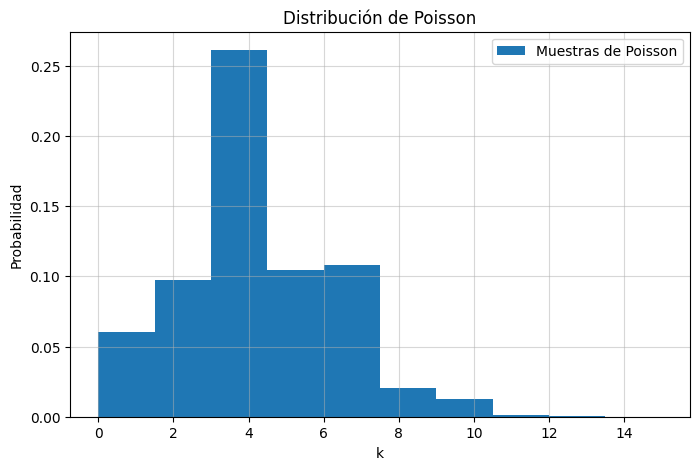

In [11]:
#Ejemplo y histograma
if __name__=='__main__':
    lam = 4
    muestras = 100000
    #Valores generados
    valores = poisson_prng(lam,muestras)
    plt.figure(figsize=(8,5))
    plt.hist(valores,bins=10,density=True,label="Muestras de Poisson")
    plt.ylabel("Probabilidad")
    plt.xlabel("k")
    plt.title('Distribución de Poisson')
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()